<a href="https://colab.research.google.com/github/2023AC05202/pytorch_tutorial_1/blob/develop/6_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid


import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#Convert MNIST image files into a tensor of 4-Dimensions( # of image, height, width, color)
transform = transforms.ToTensor()

In [3]:
#Train data
train_data = datasets.MNIST(root='mnist_data', train=True, download=True, transform=transform)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 133MB/s]


Extracting mnist_data/MNIST/raw/train-images-idx3-ubyte.gz to mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 30.8MB/s]


Extracting mnist_data/MNIST/raw/train-labels-idx1-ubyte.gz to mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 78.7MB/s]


Extracting mnist_data/MNIST/raw/t10k-images-idx3-ubyte.gz to mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.29MB/s]


Extracting mnist_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to mnist_data/MNIST/raw



In [4]:
#Test data
test_data = datasets.MNIST(root='mnist_data', train=False, download=True, transform=transform)

In [5]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: mnist_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: mnist_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [7]:
# Create a small batch size of images ...say 10
train_data_loader = DataLoader.DataLoader(train_data, batch_size=10, shuffle=True)
test_data_loader = DataLoader.DataLoader(test_data, batch_size=10, shuffle=False)

In [8]:
# Define CNN model
# Describe convolution layer and what it s doing (2 convolution layer)
conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1)
conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1)

In [9]:
# Grab 1 MNIST RECORD/ IMAGE
for i, (X_train, y_train) in enumerate(train_data):
    break

In [10]:
X_train.shape

torch.Size([1, 28, 28])

In [11]:
x = X_train.view(1,1,28,28)

In [12]:
#Perform the first convolution
x = F.relu(conv1(x))

In [13]:
# 1 -> # of image
# 6 ->  Filter we asked for
# 26 X 26 size of the image
x.shape

torch.Size([1, 6, 26, 26])

In [14]:
# pass through pooling layer of kernal size 2 and stride of 2
x = F.max_pool2d(x, 2, 2)

In [15]:
x.shape

torch.Size([1, 6, 13, 13])

In [16]:
# Go through second convolution layer
x = F.relu(conv2(x))

In [17]:
x.shape

torch.Size([1, 16, 11, 11])

In [18]:
#Pooling layer
x = F.max_pool2d(x, 2, 2)

In [19]:
x.shape

torch.Size([1, 16, 5, 5])

In [20]:
# Model class
class ConvolutionNetwork(nn.Module):
  def __init__(self):
      super(ConvolutionNetwork, self).__init__()
      self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1)
      self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1)
      #Fully connected layer
      self.fc1 = nn.Linear(5*5*16, 120)
      self.fc2 = nn.Linear(120, 84)
      self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
      # First pass
      x = F.relu(self.conv1(x))
      x = F.max_pool2d(x, 2, 2)

      # Second pass
      x = F.relu(self.conv2(x))
      x = F.max_pool2d(x, 2, 2)

      #Reshape to flatten this out
      x = x.view(-1, 16*5*5)

      #Fully Connected layer
      x = F.relu(self.fc1(x))
      x = F.relu(self.fc2(x))
      x = self.fc3(x)

      return F.log_softmax(x, dim=1)


In [21]:
torch.manual_seed(41)
model = ConvolutionNetwork()
model

ConvolutionNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [22]:
# Define loss function and optimizer
criterian = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [23]:
import time
start_time = time.time()

# Create variables to track
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

# Loop through epochs
for i in range(epochs):
  trn_corr = 0
  tst_corr = 0

  # Train
  for b, (X_train, y_train) in enumerate(train_data_loader):

    # Start our batches at 1
    b += 1

    # get the  predicted value from training set not flattened
    y_predict = model(X_train)

    # How off are we? Compare the predict with correct ones
    loss = criterian(y_predict, y_train)

    # Add up the number of predictions
    predicted = torch.max(y_predict.data, 1)[1]

    # How many we got correct
    batch_corr = (predicted == y_train).sum()

    # Keep track as we go along
    trn_corr += batch_corr

    # Backpropagate
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if b % 600 == 0:
      print(f'epoch: {i} batch: {b} loss: {loss.item()}')

  train_losses.append(loss)
  train_correct.append(trn_corr)

  # Test
  with torch.no_grad(): # No gradient so that we don't update weights and bais here
    for b, (X_test, y_test) in enumerate(test_data_loader):
      y_val = model(X_test)
      predicted = torch.max(y_val.data, 1)[1]
      tst_corr += (predicted == y_test).sum()

  loss = criterian(y_val, y_test)
  test_losses.append(loss)
  test_correct.append(tst_corr)

end_time = time.time()
print(f'Training took {(end_time - start_time)/ 60 } minutes')

epoch: 0 batch: 600 loss: 0.01122160442173481
epoch: 0 batch: 1200 loss: 0.5097795128822327
epoch: 0 batch: 1800 loss: 0.27345114946365356
epoch: 0 batch: 2400 loss: 0.5706523656845093
epoch: 0 batch: 3000 loss: 0.010505528189241886
epoch: 0 batch: 3600 loss: 0.1338011920452118
epoch: 0 batch: 4200 loss: 0.0005176571430638433
epoch: 0 batch: 4800 loss: 0.10394303500652313
epoch: 0 batch: 5400 loss: 0.2622598111629486
epoch: 0 batch: 6000 loss: 0.0009407080942764878
epoch: 1 batch: 600 loss: 0.010575367137789726
epoch: 1 batch: 1200 loss: 0.004694225732237101
epoch: 1 batch: 1800 loss: 0.06041830778121948
epoch: 1 batch: 2400 loss: 0.08412185311317444
epoch: 1 batch: 3000 loss: 1.2497214078903198
epoch: 1 batch: 3600 loss: 0.5397676229476929
epoch: 1 batch: 4200 loss: 0.005220157094299793
epoch: 1 batch: 4800 loss: 0.0007686594035476446
epoch: 1 batch: 5400 loss: 0.0005603323224931955
epoch: 1 batch: 6000 loss: 0.08629796653985977
epoch: 2 batch: 600 loss: 0.6476114988327026
epoch: 2 ba

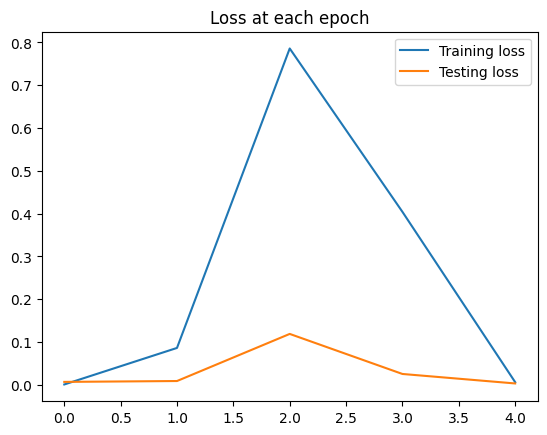

In [24]:
# Graph the loss at each epoch
train_losses = [t.cpu().detach().numpy() for t in train_losses]
test_losses = [t.cpu().detach().numpy() for t in test_losses]
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Testing loss')
plt.title('Loss at each epoch')
plt.legend()

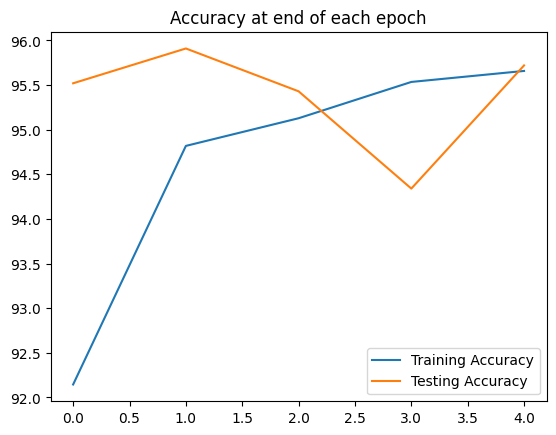

In [25]:
# Graph the accuracy at end of each epoch
plt.plot([t/600 for t in train_correct], label='Training Accuracy')
plt.plot([t/100 for t in test_correct], label='Testing Accuracy')
plt.title('Accuracy at end of each epoch')
plt.legend()

In [26]:
test_load_everything = DataLoader.DataLoader(test_data, batch_size=10000, shuffle=False)

In [27]:
with torch.no_grad():
  correct = 0
  for images, labels in test_load_everything:
    test_output = model(images)
    predicted = torch.max(test_output, 1)[1]
    correct += (predicted == labels).sum()

In [28]:
# Get the accuracy percentage
correct.item()/len(test_data)

0.9572

In [29]:
#Grab the image
test_data[4123]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [30]:
test_data[4123][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [31]:
test_data[4123][0].reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

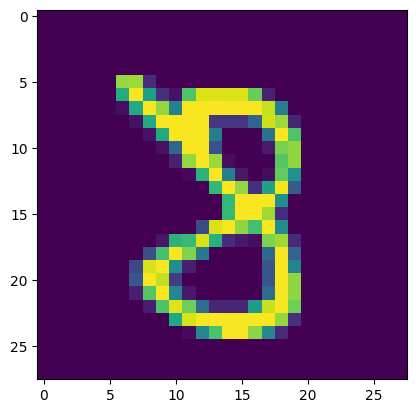

In [32]:
plt.imshow(test_data[4123][0].reshape(28,28))

In [33]:
# Pass the image through model
model.eval()
with torch.no_grad():
  new_prediction = model(test_data[4123][0].view(1,1,28,28))

In [34]:
# Check the new prediction... get probability
new_prediction

tensor([[ -8.5704,  -8.0864,  -4.7145,  -4.5695,  -8.5590,  -7.8866,  -9.0961,
         -11.1390,  -0.0226,  -6.3042]])

In [35]:
new_prediction.argmax()

tensor(8)